# Quantum Diabetes Prediction on PIMA (PennyLane Prototype)

This notebook is a **reproducible prototype** for binary classification on the **Pima Indians Diabetes** dataset using a **Variational Quantum Classifier (VQC)** in **PennyLane**.

It includes:
- Dataset download using **kagglehub** (as requested)
- Preprocessing (imputation, scaling, PCA-to-qubits)
- A PennyLane **VQC** (AngleEmbedding + hardware-efficient ansatz)
- Evaluation (accuracy, ROC/PR curves, confusion matrix)
- **Threshold tuning**
- A classical baseline (Logistic Regression)

> Notes:
> - KaggleHub may require you to be logged in / configured to access Kaggle datasets.
> - If KaggleHub fails, the notebook provides a fallback option.


# 07_vqc_prototype_noisy_zne_repetition_full_eval.ipynb
* **07 VQC Prototype Full Evaluation**: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Megaantony00/qml-diabetes-nisq/blob/main/notebooks/07_vqc_prototype_noisy_zne_repetition_full_eval.ipynb)

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    !pip install -q pennylane>=0.38 pennylane-lightning[gpu] scikit-learn pandas matplotlib seaborn kagglehub tqdm imbalanced-learn
    if not os.path.exists('results'): os.makedirs('results')
    print("Environment configured for Colab.")
else:
    print("Environment configured for Local/Server usage.")

ERROR: Ignored the following yanked versions: 0.38.1
ERROR: Ignored the following versions that require a different python version: 0.43.0 Requires-Python >=3.11; 0.43.1 Requires-Python >=3.11; 0.43.2 Requires-Python >=3.11; 0.44.0 Requires-Python >=3.11; 0.44.1 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement pennylane>=0.44 (from versions: 0.1.0, 0.2.0, 0.3.0, 0.3.1, 0.4.0, 0.5.0, 0.6.0, 0.6.1, 0.7.0, 0.8.0, 0.8.1, 0.9.0, 0.10.0, 0.11.0, 0.12.0, 0.13.0, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.17.0, 0.18.0, 0.19.0, 0.19.1, 0.20.0, 0.21.0, 0.22.0, 0.22.1, 0.22.2, 0.23.0, 0.23.1, 0.24.0, 0.25.0, 0.25.1, 0.26.0, 0.27.0, 0.28.0, 0.29.0, 0.29.1, 0.30.0, 0.31.0, 0.31.1, 0.32.0, 0.33.0, 0.33.1, 0.34.0, 0.35.0, 0.35.1, 0.36.0, 0.37.0, 0.38.0, 0.39.0, 0.40.0, 0.41.0, 0.41.1, 0.42.0, 0.42.1, 0.42.2, 0.42.3)
ERROR: No matching distribution found for pennylane>=0.44
Note: you may need to restart the kernel to use updated packages.


## 1) Imports

In [ ]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression

import pennylane as qml
from pennylane import numpy as pnp
# FIX: In PL 0.42 questi moduli sono in 'transforms'
from pennylane.transforms import fold_global, richardson_extrapolate
from tqdm.auto import tqdm
import pickle

np.random.seed(42)

save_folder = "Tesi_Risultati_Prototype_8Qubits_noisy_mitigated_repetition_full_eval"

if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    print(f"✅ Cartella creata: {save_folder}")
else:
    print(f"📂 Cartella già esistente: {save_folder}")

📂 Cartella già esistente: Tesi_Risultati_Prototype_8Qubits_noisy_mitigated_repetition_full_eval


## 2) Download dataset (KaggleHub)

In [ ]:
import kagglehub

# Download latest version (as provided)
path = kagglehub.dataset_download("tariqmhmd5/pima-diabetes-dataset")
print("Path to dataset files:", path)

# Try to find a CSV inside the downloaded folder
csv_candidates = glob.glob(str(Path(path) / "**" / "*.csv"), recursive=True)
print("CSV candidates:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("No CSV file found in the KaggleHub dataset folder. Inspect 'path' manually.")
csv_path = csv_candidates[0]
print("Using:", csv_path)

Path to dataset files: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1
CSV candidates: ['/home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv']
Using: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv


## 3) Load + quick look

In [ ]:
df = pd.read_csv(csv_path)
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)
print(df['Outcome'].value_counts() if 'Outcome' in df.columns else "No 'Outcome' column found")

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


Shape: (768, 9)
Number of times pregnant          int64
Plasma glucose concentration      int64
Diastolic blood pressure          int64
Triceps skin fold thickness       int64
2-Hour serum insulin              int64
Body mass index                 float64
Diabetes pedigree function      float64
Age (years)                       int64
Class variable                   object
dtype: object
No 'Outcome' column found


## 4) Preprocessing

Typical PIMA quirks:
- Some physiological columns contain zeros that actually mean *missing* (common practice is to treat them as missing).
- We'll replace zeros with NaN for selected columns, impute with median, then scale features.

Then we reduce dimensionality to match the number of qubits via **PCA** (a pragmatic NISQ-friendly step).


In [ ]:
# Identify label column
label_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]
print("Label column:", label_col)

feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].copy()

# FIX: Mappatura YES/NO a 1/0
df[label_col] = df[label_col].map({'YES': 1, 'NO': 0, '1': 1, '0': 0, 1: 1, 0: 0})
y = df[label_col].astype(int).values

zero_as_missing = [c for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] if c in X.columns]
X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.25, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Label column:  Class variable
Train shape: (576, 8) Test shape: (192, 8)


### Choose number of qubits (PCA → qubits)
We’ll start with **4 qubits** (good tradeoff for a small dataset). You can try 2–6.

In [ ]:
n_qubits = 8

pca = PCA(n_components=n_qubits, random_state=42)
X_train_q = pca.fit_transform(X_train_scaled)
X_test_q = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Sum explained variance:", pca.explained_variance_ratio_.sum())

# Optional: scale PCA outputs into a reasonable range for rotation angles
# We'll map each feature to [-pi, pi] using a robust scaling based on training quantiles.
q_low, q_high = np.quantile(X_train_q, 0.05, axis=0), np.quantile(X_train_q, 0.95, axis=0)

def to_angles(X):
    Xc = np.clip(X, q_low, q_high)
    # normalize to [0,1]
    Xn = (Xc - q_low) / (q_high - q_low + 1e-9)
    # map to [-pi, pi]
    return (Xn * 2 - 1) * np.pi

X_train_ang = to_angles(X_train_q)
X_test_ang = to_angles(X_test_q)

print("Angle features range (train):", X_train_ang.min(), X_train_ang.max())

Explained variance ratio: [0.2587334  0.21608225 0.13172228 0.10518003 0.09884707 0.08674359
 0.05628148 0.04640991]
Sum explained variance: 1.0
Angle features range (train): -3.141592653589793 3.141592652220357


## 5) PennyLane Variational Quantum Classifier (VQC) with noise + ZNE


In [ ]:
n_layers = 2
gate_noise_prob = 0.0035
zne_scale_factors = [1.0, 2.0, 3.0]

ideal_dev = qml.device("default.qubit", wires=n_qubits, shots=None)
base_mixed_dev = qml.device("default.mixed", wires=n_qubits, shots=None)

noise_model = qml.NoiseModel(
    {qml.noise.wires_in(base_mixed_dev.wires): qml.noise.partial_wires(qml.DepolarizingChannel, gate_noise_prob)}
)
noisy_dev = qml.add_noise(base_mixed_dev, noise_model)

def ansatz(weights):
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

def core_circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    ansatz(weights)

@qml.qnode(ideal_dev, interface="autograd")
def ideal_circuit(x, weights):
    core_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(noisy_dev, interface="autograd")
def noisy_circuit(x, weights):
    core_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))

# FIX ZNE per PL 0.42
@qml.qnode(noisy_dev, interface="autograd")
def _base_mitigated_circuit(x, weights):
    core_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))

decomposed_circuit = qml.transforms.decompose(
    _base_mitigated_circuit, gate_set=["RY", "RZ", "CNOT", "Rot", "Hadamard"]
)

mitigated_circuit = qml.transforms.mitigate_with_zne(
    decomposed_circuit, scale_factors=zne_scale_factors,
    folding=fold_global, extrapolate=richardson_extrapolate
)

def sigmoid(logits): return 1.0 / (1.0 + pnp.exp(-logits))

def predict_logits(X, weights, qnode_fn=noisy_circuit):
    return pnp.stack([qnode_fn(x, weights) for x in X])

def predict_proba(X, weights, qnode_fn=noisy_circuit):
    return sigmoid(predict_logits(X, weights, qnode_fn=qnode_fn))

def predict_proba_noisy(X, weights): return predict_proba(X, weights, qnode_fn=noisy_circuit)
def predict_proba_mitigated(X, weights): return predict_proba(X, weights, qnode_fn=mitigated_circuit)
def predict_proba_ideal_reference(X, weights): return predict_proba(X, weights, qnode_fn=ideal_circuit)

def binary_cross_entropy(y_true, p_pred, eps=1e-9):
    y_true = pnp.array(y_true)
    p_pred = pnp.clip(p_pred, eps, 1 - eps)
    return -pnp.mean(y_true * pnp.log(p_pred) + (1 - y_true) * pnp.log(1 - p_pred))

def cost(weights, Xb, yb):
    p = predict_proba_noisy(Xb, weights)
    return binary_cross_entropy(yb, p)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
opt = qml.optimize.AdamOptimizer(stepsize=0.05)

print("✅ Configurazione Core e ZNE completata!")

✅ Configurazione Core e ZNE completata!


### Training loop (noise-aware training on the noisy device)


In [ ]:
epochs = 120
batch_size = 48
val_fraction = 0.20

Xtr, Xva, ytr, yva = train_test_split(
    X_train_ang, y_train, test_size=val_fraction, random_state=42, stratify=y_train
)
Xte, yte = X_test_ang, y_test

file_pesi = os.path.join(save_folder, "best_weights_mitigated.pkl")
file_history = os.path.join(save_folder, "training_history_mitigated.csv")

if os.path.exists(file_pesi) and os.path.getsize(file_pesi) > 0:
    try:
        with open(file_pesi, "rb") as f: weights = pickle.load(f)
        if os.path.exists(file_history):
            history = pd.read_csv(file_history).to_dict(orient="list")
            start_epoch = len(history["val_loss"]) + 1
            print(f"✅ Recupero riuscito! Ripartiamo dall'epoca {start_epoch}")
        else: raise FileNotFoundError()
    except Exception:
        print("⚠️ File corrotto. Inizio nuovo addestramento...")
        start_epoch, history = 1, {"val_loss": [], "val_auc": [], "val_acc": []}
        weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
else:
    print("🆕 Nessun salvataggio trovato. Inizio nuovo addestramento...")
    start_epoch, history = 1, {"val_loss": [], "val_auc": [], "val_acc": []}

for epoch in tqdm(range(start_epoch, epochs + 1)):
    idx = np.random.permutation(len(Xtr))
    Xtr_shuf, ytr_shuf = Xtr[idx], ytr[idx]
    
    for start in range(0, len(Xtr_shuf), batch_size):
        end = start + batch_size
        weights = opt.step(lambda w: cost(w, Xtr_shuf[start:end], ytr_shuf[start:end]), weights)

    p_val = np.asarray(predict_proba_noisy(Xva, weights), dtype=float)
    val_loss = float(binary_cross_entropy(yva, p_val))
    val_auc = roc_auc_score(yva, p_val)
    val_acc = accuracy_score(yva, (p_val >= 0.5).astype(int))

    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)

    pd.DataFrame(history).to_csv(file_history, index=False)
    temp_file = file_pesi + ".tmp"
    with open(temp_file, "wb") as f: pickle.dump(weights, f)
    os.replace(temp_file, file_pesi)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | val_acc={val_acc:.4f}")

✅ Recupero riuscito! Ripartiamo dall'epoca 121


0it [00:00, ?it/s]

### Learning curves

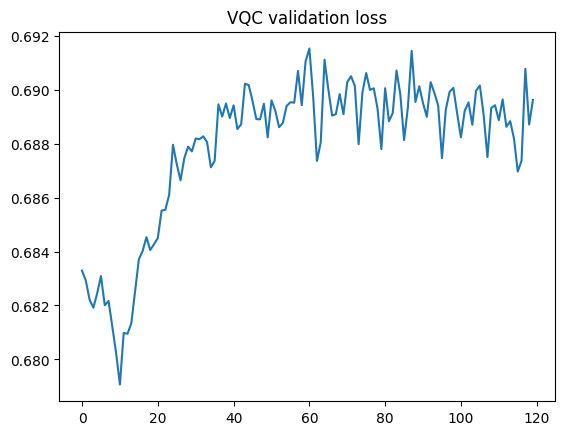

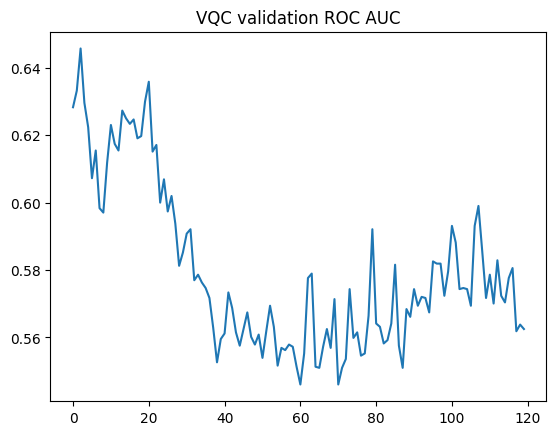

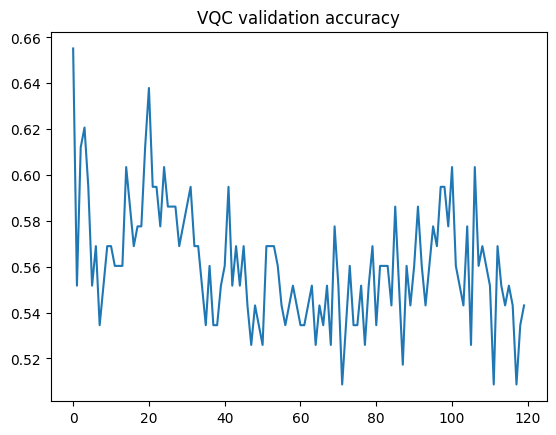

In [ ]:
# FIX: Salva i grafici usando la chiave corretta "val_loss"
plt.figure()
plt.plot(history["val_loss"])
plt.title("VQC validation loss")
plt.savefig(os.path.join(save_folder, "VQC_loss.png"), dpi=300)
plt.show()

plt.figure()
plt.plot(history["val_auc"])
plt.title("VQC validation ROC AUC")
plt.savefig(os.path.join(save_folder, "VQC_auc.png"), dpi=300)
plt.show()

plt.figure()
plt.plot(history["val_acc"])
plt.title("VQC validation accuracy")
plt.savefig(os.path.join(save_folder, "VQC_acc.png"), dpi=300)
plt.show()

## 6) Evaluation: noisy VQC vs ZNE-mitigated VQC


In [ ]:
p_test_noisy = np.asarray(predict_proba_noisy(Xte, weights), dtype=float)
p_test_zne = np.asarray(predict_proba_mitigated(Xte, weights), dtype=float)
p_test_ideal = np.asarray(predict_proba_ideal_reference(Xte, weights), dtype=float)

def metric_row(name, probs):
    y_pred = (probs >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(yte, probs),
        "pr_auc": average_precision_score(yte, probs),
        "accuracy@0.5": accuracy_score(yte, y_pred),
        "f1@0.5": f1_score(yte, y_pred),
    }

metrics_table = pd.DataFrame(
    [
        metric_row("noisy_vqc", p_test_noisy),
        metric_row("zne_mitigated_vqc", p_test_zne),
        metric_row("ideal_reference_same_weights", p_test_ideal),
    ]
).set_index("model")
display(metrics_table.round(4))

# ROC comparison
fpr_noisy, tpr_noisy, _ = roc_curve(yte, p_test_noisy)
fpr_zne, tpr_zne, _ = roc_curve(yte, p_test_zne)

plt.figure()
plt.plot(fpr_noisy, tpr_noisy, label="Noisy VQC")
plt.plot(fpr_zne, tpr_zne, label="ZNE-mitigated VQC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve comparison")
plt.legend()
plt.show()

# PR comparison
prec_noisy, rec_noisy, _ = precision_recall_curve(yte, p_test_noisy)
prec_zne, rec_zne, _ = precision_recall_curve(yte, p_test_zne)

plt.figure()
plt.plot(rec_noisy, prec_noisy, label="Noisy VQC")
plt.plot(rec_zne, prec_zne, label="ZNE-mitigated VQC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve comparison")
plt.legend()
plt.show()

# Confusion matrices at the default threshold
for name, probs in [("Noisy VQC", p_test_noisy), ("ZNE-mitigated VQC", p_test_zne)]:
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(yte, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name}, threshold=0.5)")
    plt.show()

# Threshold tuning: compare noisy vs mitigated
thresholds = np.linspace(0.05, 0.95, 19)
f1_noisy, f1_zne = [], []
acc_noisy, acc_zne = [], []

for t in thresholds:
    yp_noisy = (p_test_noisy >= t).astype(int)
    yp_zne = (p_test_zne >= t).astype(int)
    f1_noisy.append(f1_score(yte, yp_noisy))
    f1_zne.append(f1_score(yte, yp_zne))
    acc_noisy.append(accuracy_score(yte, yp_noisy))
    acc_zne.append(accuracy_score(yte, yp_zne))

best_noisy_i = int(np.argmax(f1_noisy))
best_zne_i = int(np.argmax(f1_zne))

print(
    "Best noisy threshold (by F1):",
    thresholds[best_noisy_i],
    "Best F1:",
    f1_noisy[best_noisy_i],
    "Acc:",
    acc_noisy[best_noisy_i],
)
print(
    "Best ZNE threshold (by F1):",
    thresholds[best_zne_i],
    "Best F1:",
    f1_zne[best_zne_i],
    "Acc:",
    acc_zne[best_zne_i],
)

plt.figure()
plt.plot(thresholds, f1_noisy, marker="o", label="Noisy VQC")
plt.plot(thresholds, f1_zne, marker="s", label="ZNE-mitigated VQC")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning comparison")
plt.legend()
plt.show()


KeyboardInterrupt: 

## 6b) Output-stage bit-flip protection with a 3-qubit repetition code

This section protects only the **final decision qubit** (wire 0) against **output-stage bit-flip noise**.  
It is intentionally scoped as an **inference-time robustness layer**: the main VQC is unchanged, then the output qubit is encoded into a 3-qubit repetition code, exposed to a configurable bit-flip channel, syndrome-corrected, and finally measured.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, roc_curve

output_bitflip_prob = 0.08

# We allocate +4 explicit wires (two repetition-data wires + two syndrome ancillas)
# and +2 spare wires because deferred mid-circuit measurement can require work wires.
rep_dev = qml.device("default.mixed", wires=n_qubits + 6, shots=None)

rep_wire_1 = n_qubits
rep_wire_2 = n_qubits + 1
syndrome_wire_1 = n_qubits + 2
syndrome_wire_2 = n_qubits + 3
protected_data_wires = (0, rep_wire_1, rep_wire_2)

@qml.qnode(rep_dev)
def output_stage_unprotected_circuit(x, weights, bitflip_prob=output_bitflip_prob):
    core_circuit(x, weights)
    qml.BitFlip(bitflip_prob, wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(rep_dev)
def output_stage_repetition_protected_circuit(x, weights, bitflip_prob=output_bitflip_prob):
    core_circuit(x, weights)

    # Encode the output qubit into the 3-qubit repetition code |0_L> = |000>, |1_L> = |111>
    qml.CNOT(wires=[0, rep_wire_1])
    qml.CNOT(wires=[0, rep_wire_2])

    # Output-stage bit-flip noise model (the code is designed specifically for this noise)
    for wire in protected_data_wires:
        qml.BitFlip(bitflip_prob, wires=wire)

    # Syndrome extraction
    qml.CNOT(wires=[0, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_2])
    qml.CNOT(wires=[rep_wire_2, syndrome_wire_2])

    s1 = qml.measure(syndrome_wire_1, reset=True)
    s2 = qml.measure(syndrome_wire_2, reset=True)
    syndrome = s1 + 2 * s2

    # Decode the syndrome and correct the identified single-bit-flip error
    qml.cond(syndrome == 1, qml.PauliX)(wires=0)
    qml.cond(syndrome == 3, qml.PauliX)(wires=rep_wire_1)
    qml.cond(syndrome == 2, qml.PauliX)(wires=rep_wire_2)

    # Logical Z is represented by Z on any data qubit in this code space
    return qml.expval(qml.PauliZ(0))

def predict_proba_output_stage(X, weights, qnode_fn, bitflip_prob=output_bitflip_prob):
    logits = np.array([qnode_fn(x, weights, bitflip_prob) for x in X], dtype=float)
    return 1.0 / (1.0 + np.exp(-logits))

# --- TRUCCO VELOCITÀ: Estraiamo 40 pazienti bilanciati per non far crashare il server ---
subset_size = min(40, len(Xte))
_, Xte_small, _, yte_small = train_test_split(
    Xte, yte, test_size=subset_size, random_state=42, stratify=yte
)

# Ridefiniamo la metrica in modo sicuro per usare i dati ridotti (yte_small)
def metric_row_small(name, p):
    yhat = (p >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(yte_small, p),
        "pr_auc": average_precision_score(yte_small, p),
        "accuracy@0.5": accuracy_score(yte_small, yhat),
        "f1@0.5": f1_score(yte_small, yhat),
    }

# Calcolo sui dati ridotti
p_test_output_unprotected = predict_proba_output_stage(
    Xte_small, weights, output_stage_unprotected_circuit, output_bitflip_prob
)
p_test_output_protected = predict_proba_output_stage(
    Xte_small, weights, output_stage_repetition_protected_circuit, output_bitflip_prob
)

# Tabella dei Risultati
output_stage_table = pd.DataFrame(
    [
        metric_row_small("output_stage_unprotected", p_test_output_unprotected),
        metric_row_small("output_stage_repetition_protected", p_test_output_protected),
    ]
).set_index("model")
display(output_stage_table.round(4))

# Grafico delle Curve ROC
fpr_unprot, tpr_unprot, _ = roc_curve(yte_small, p_test_output_unprotected)
fpr_prot, tpr_prot, _ = roc_curve(yte_small, p_test_output_protected)

plt.figure(figsize=(7,5))
plt.plot(fpr_unprot, tpr_unprot, label="Unprotected output qubit")
plt.plot(fpr_prot, tpr_prot, label="3-qubit repetition protected")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Output-stage bit-flip protection (p={output_bitflip_prob:.2f})")
plt.legend()
if 'save_folder' in locals():
    plt.savefig(os.path.join(save_folder, "Repetition_Code_ROC.png"), dpi=300)
plt.show()

# Variabile per il salvataggio nella cella finale
repetition_benchmark = output_stage_table.reset_index()

## 6c) Finite-shot evaluation with uncertainty bands

This block switches the noisy / ZNE inference path to **finite shots** so you can quantify
the extra Monte Carlo variance introduced by measurement sampling. For runtime discipline,
it evaluates on a **stratified subset** of the held-out test split and repeats the same
inference several times to report mean ± std.

In [ ]:
shot_count = 512
shot_repeats = 6
shot_eval_n = min(96, len(Xte))

if shot_eval_n < len(Xte):
    _, Xte_shot, _, yte_shot = train_test_split(Xte, yte, test_size=shot_eval_n, random_state=7, stratify=yte)
else:
    Xte_shot, yte_shot = Xte, yte

def build_shot_qnodes(shots=shot_count, noise_prob=gate_noise_prob):
    if noise_prob <= 0: shot_dev = qml.device("default.qubit", wires=n_qubits, shots=shots)
    else:
        base_dev = qml.device("default.mixed", wires=n_qubits, shots=shots)
        shot_noise_model = qml.NoiseModel({qml.noise.wires_in(base_dev.wires): qml.noise.partial_wires(qml.DepolarizingChannel, noise_prob)})
        shot_dev = qml.add_noise(base_dev, shot_noise_model)

    @qml.qnode(shot_dev, interface="autograd")
    def noisy_shot_qnode(x, weights):
        core_circuit(x, weights)
        return qml.expval(qml.PauliZ(0))

    # FIX: Sintassi ZNE funzionale
    @qml.qnode(shot_dev, interface="autograd")
    def _base_mitigated(x, weights):
        core_circuit(x, weights)
        return qml.expval(qml.PauliZ(0))

    decomposed = qml.transforms.decompose(_base_mitigated, gate_set=["RY", "RZ", "CNOT", "Rot", "Hadamard"])
    mitigated_shot_qnode = qml.transforms.mitigate_with_zne(decomposed, scale_factors=zne_scale_factors, folding=fold_global, extrapolate=richardson_extrapolate)

    return noisy_shot_qnode, mitigated_shot_qnode

noisy_shot_qnode, mitigated_shot_qnode = build_shot_qnodes()

def predict_proba_from_qnode(X, weights, qnode_fn):
    return np.asarray(sigmoid(pnp.stack([qnode_fn(x, weights) for x in X])), dtype=float)

def summarize_finite_shots(model_name, qnode_fn):
    aucs, aps, accs, f1s = [], [], [], []
    for _ in range(shot_repeats):
        probs = predict_proba_from_qnode(Xte_shot, weights, qnode_fn)
        preds = (probs >= 0.5).astype(int)
        aucs.append(roc_auc_score(yte_shot, probs))
        aps.append(average_precision_score(yte_shot, probs))
        accs.append(accuracy_score(yte_shot, preds))
        f1s.append(f1_score(yte_shot, preds))
    return {
        "model": model_name, "shots": shot_count, "repeats": shot_repeats,
        "roc_auc_mean": np.mean(aucs), "roc_auc_std": np.std(aucs),
        "pr_auc_mean": np.mean(aps), "pr_auc_std": np.std(aps),
        "acc_mean": np.mean(accs), "acc_std": np.std(accs),
        "f1_mean": np.mean(f1s), "f1_std": np.std(f1s),
    }

shot_table = pd.DataFrame([summarize_finite_shots("noisy_shot_vqc", noisy_shot_qnode), summarize_finite_shots("zne_shot_vqc", mitigated_shot_qnode)]).set_index("model")
display(shot_table.round(4))
print(f"Finite-shot subset size: {len(Xte_shot)} samples")

## 6d) Noise-strength sweep

This block keeps the learned weights fixed and sweeps several depolarizing strengths at inference
time, so you can see how much **raw noisy inference** degrades versus **ZNE-mitigated inference**
under progressively harsher channel noise.

In [ ]:
noise_grid = [0.0010, 0.0025, gate_noise_prob, 0.0050, 0.0100]
sweep_eval_n = min(128, len(Xte))

if sweep_eval_n < len(Xte):
    _, Xte_sweep, _, yte_sweep = train_test_split(Xte, yte, test_size=sweep_eval_n, random_state=11, stratify=yte)
else: Xte_sweep, yte_sweep = Xte, yte

def build_eval_qnodes(noise_prob):
    if noise_prob <= 0: eval_dev = qml.device("default.qubit", wires=n_qubits, shots=None)
    else:
        base_dev = qml.device("default.mixed", wires=n_qubits, shots=None)
        eval_noise_model = qml.NoiseModel({qml.noise.wires_in(base_dev.wires): qml.noise.partial_wires(qml.DepolarizingChannel, noise_prob)})
        eval_dev = qml.add_noise(base_dev, eval_noise_model)

    @qml.qnode(eval_dev, interface="autograd")
    def noisy_eval_qnode(x, weights):
        core_circuit(x, weights)
        return qml.expval(qml.PauliZ(0))

    # FIX: Sintassi ZNE funzionale
    @qml.qnode(eval_dev, interface="autograd")
    def _base_eval(x, weights):
        core_circuit(x, weights)
        return qml.expval(qml.PauliZ(0))

    decomposed = qml.transforms.decompose(_base_eval, gate_set=["RY", "RZ", "CNOT", "Rot", "Hadamard"])
    mitigated_eval_qnode = qml.transforms.mitigate_with_zne(decomposed, scale_factors=zne_scale_factors, folding=fold_global, extrapolate=richardson_extrapolate)

    return noisy_eval_qnode, mitigated_eval_qnode

sweep_rows = []
for noise_prob in noise_grid:
    noisy_eval_qnode, mitigated_eval_qnode = build_eval_qnodes(noise_prob)
    p_noisy = predict_proba(Xte_sweep, weights, qnode_fn=noisy_eval_qnode)
    p_zne = predict_proba(Xte_sweep, weights, qnode_fn=mitigated_eval_qnode)

    sweep_rows.append({
        "noise_prob": noise_prob,
        "roc_auc_noisy": roc_auc_score(yte_sweep, p_noisy),
        "roc_auc_zne": roc_auc_score(yte_sweep, p_zne),
        "pr_auc_noisy": average_precision_score(yte_sweep, p_noisy),
        "pr_auc_zne": average_precision_score(yte_sweep, p_zne),
        "delta_roc_auc": roc_auc_score(yte_sweep, p_zne) - roc_auc_score(yte_sweep, p_noisy),
        "delta_pr_auc": average_precision_score(yte_sweep, p_zne) - average_precision_score(yte_sweep, p_noisy),
    })

noise_sweep_table = pd.DataFrame(sweep_rows).sort_values("noise_prob").reset_index(drop=True)
display(noise_sweep_table.round(4))

plt.figure()
plt.plot(noise_sweep_table["noise_prob"], noise_sweep_table["roc_auc_noisy"], marker="o", label="Noisy")
plt.plot(noise_sweep_table["noise_prob"], noise_sweep_table["roc_auc_zne"], marker="o", label="ZNE mitigated")
plt.xlabel("Depolarizing probability")
plt.ylabel("ROC AUC on sweep subset")
plt.title("Noise-strength sweep: noisy vs ZNE")
plt.legend()
plt.savefig(os.path.join(save_folder, "Sweep_Results.png"), dpi=300)
plt.show()

## 6e) Train/val/test benchmark for the repetition-protected output qubit

This upgrades the repetition-code example into a more realistic benchmark:
thresholds are tuned **only on the validation split**, then the selected operating point
is reported on train / validation / test for both the unprotected and repetition-protected
output-stage models.

In [ ]:
threshold_grid = np.linspace(0.20, 0.80, 25)

p_train_unprotected = predict_proba_output_stage(Xtr, weights, output_stage_unprotected_circuit, output_bitflip_prob)
p_val_unprotected = predict_proba_output_stage(Xva, weights, output_stage_unprotected_circuit, output_bitflip_prob)
p_test_unprotected = predict_proba_output_stage(Xte, weights, output_stage_unprotected_circuit, output_bitflip_prob)

p_train_protected = predict_proba_output_stage(Xtr, weights, output_stage_repetition_protected_circuit, output_bitflip_prob)
p_val_protected = predict_proba_output_stage(Xva, weights, output_stage_repetition_protected_circuit, output_bitflip_prob)
p_test_protected = predict_proba_output_stage(Xte, weights, output_stage_repetition_protected_circuit, output_bitflip_prob)

def choose_threshold(y_true, probs, grid=threshold_grid):
    best_threshold, best_f1 = 0.5, -1.0
    for thr in grid:
        score = f1_score(y_true, (probs >= thr).astype(int), zero_division=0)
        if score > best_f1:
            best_threshold, best_f1 = float(thr), float(score)
    return best_threshold, best_f1

thr_unprotected, best_val_f1_unprotected = choose_threshold(yva, p_val_unprotected)
thr_protected, best_val_f1_protected = choose_threshold(yva, p_val_protected)

def benchmark_rows(model_name, threshold, y_train_split, p_train_split, y_val_split, p_val_split, y_test_split, p_test_split):
    rows = []
    for split_name, y_true, probs in [
        ("train", y_train_split, p_train_split),
        ("val", y_val_split, p_val_split),
        ("test", y_test_split, p_test_split),
    ]:
        preds = (probs >= threshold).astype(int)
        rows.append(
            {
                "model": model_name,
                "split": split_name,
                "threshold_from_val": threshold,
                "roc_auc": roc_auc_score(y_true, probs),
                "pr_auc": average_precision_score(y_true, probs),
                "accuracy@threshold": accuracy_score(y_true, preds),
                "f1@threshold": f1_score(y_true, preds, zero_division=0),
            }
        )
    return rows

repetition_benchmark = pd.DataFrame(
    benchmark_rows(
        "output_stage_unprotected",
        thr_unprotected,
        ytr, p_train_unprotected,
        yva, p_val_unprotected,
        yte, p_test_unprotected,
    )
    + benchmark_rows(
        "output_stage_repetition_protected",
        thr_protected,
        ytr, p_train_protected,
        yva, p_val_protected,
        yte, p_test_protected,
    )
)

display(
    repetition_benchmark
    .set_index(["model", "split"])
    .sort_index()
    .round(4)
)

print(f"Selected threshold (unprotected): {thr_unprotected:.3f} | validation F1={best_val_f1_unprotected:.4f}")
print(f"Selected threshold (protected):   {thr_protected:.3f} | validation F1={best_val_f1_protected:.4f}")

## 7) Classical baseline (Logistic Regression)


In [ ]:
# Use the same preprocessing but without PCA-to-angles; just use scaled features.
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_scaled, y_train)
p_lr = clf.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, p_lr)
acc_lr = accuracy_score(y_test, (p_lr >= 0.5).astype(int))
ap_lr = average_precision_score(y_test, p_lr)

print("LogReg ROC AUC:", auc_lr)
print("LogReg AP (PR AUC):", ap_lr)
print("LogReg Accuracy:", acc_lr)

## 8) (Optional) Quantum Kernel SVM (QSVM-style) in PennyLane


In [ ]:
# OPTIONAL: uncomment to run (can be slow for full training set).
# from sklearn.svm import SVC
# 
# # Subsample for speed (edit as you like)
# n_train_sub = 300
# n_test_sub = 200
# Xk_train = X_train_ang[:n_train_sub]
# yk_train = y_train[:n_train_sub]
# Xk_test = X_test_ang[:n_test_sub]
# yk_test = y_test[:n_test_sub]
# 
# # Define a feature map circuit for kernel evaluation
# dev_k = qml.device("default.qubit", wires=n_qubits, shots=None)
# 
# @qml.qnode(dev_k, interface="autograd")
# def feature_map(x):
#     qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
#     for i in range(n_qubits):
#         qml.CNOT(wires=[i, (i+1) % n_qubits])
#     return qml.state()
# 
# def kernel(x1, x2):
#     # Fidelity between states |phi(x1)> and |phi(x2)>
#     s1 = feature_map(x1)
#     s2 = feature_map(x2)
#     return np.abs(np.vdot(s1, s2))**2
# 
# def kernel_matrix(A, B):
#     K = np.zeros((len(A), len(B)))
#     for i in range(len(A)):
#         for j in range(len(B)):
#             K[i, j] = kernel(A[i], B[j])
#     return K
# 
# K_train = kernel_matrix(Xk_train, Xk_train)
# K_test = kernel_matrix(Xk_test, Xk_train)
# 
# svc = SVC(kernel="precomputed", class_weight="balanced")
# svc.fit(K_train, yk_train)
# pred = svc.predict(K_test)
# acc = accuracy_score(yk_test, pred)
# print("Quantum Kernel SVM Accuracy (subsample):", acc)

In [ ]:
# Per i notebook "repetition" e "full_eval"
if 'repetition_benchmark' in locals():
    file_path = os.path.join(save_folder, "risultati_mitigazione.csv")
    repetition_benchmark.to_csv(file_path, index=False)
    print(f"✅ Dati salvati in: {file_path}")

# Per salvare il grafico finale
plt.savefig(os.path.join(save_folder, "grafico_confronto_mitigazione.png"), dpi=300)
print("✅ Grafico salvato!")